# IGT Simulation

In [14]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [15]:
TIME_RESOLUTION = 0.01


THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
CURVATURE = 1

In [16]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

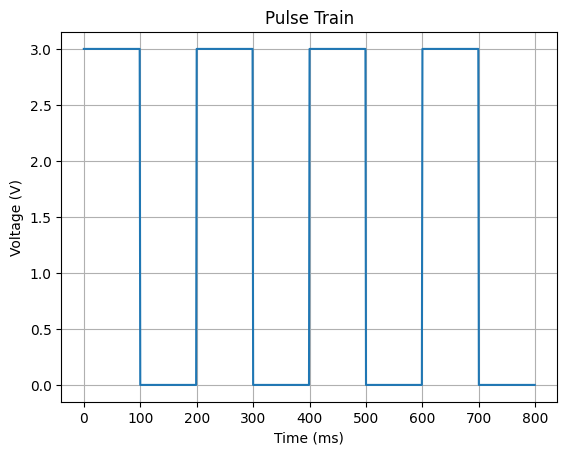

In [17]:
pulse_train = np.repeat(create_pulse_train(
    basic_voltage = 0,
    pulse_voltage = 3,
    pulse_duration = 10,
    interval_duration = 10, 
    pulse_quantity = 4
), TIME_RESOLUTION * 1000)

time = range(len(pulse_train))

plt.plot(time, pulse_train)
plt.title("Pulse Train")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.grid()
plt.show()

In [18]:
def evolve_IGT(k, v, In_1, beta, tau, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    current_in_infinity = (k * (1 - np.exp(-((v - threshold_voltage) / scale_voltage) ** curvature)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def plot_out_current(pulse_train, out_current, title, ranges):
    time = np.arange(len(out_current)) * TIME_RESOLUTION

    _, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(6, 4),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # Pulse train
    ax1.step(time, pulse_train, where="post")
    ax1.set_ylabel("Pulse")
    ax1.set_title(title)
    ax1.grid(True)

    # Out Current
    ax2.plot(time, out_current)
    ax2.scatter(time, out_current, facecolors="none", edgecolors="tab:blue")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel(r"$I_{DS}\ (nA)$")
    ax2.grid(True)
    if ranges != ((0,0),(0,0)):
        ax2.set_xlim(ranges[0])
        ax2.set_ylim(ranges[1])

    plt.tight_layout()
    plt.show()

def generate_out_current(pulse_train, k, beta, tau, plot=False, title="", ranges=((0,0),(0,0))):
    
    out_current = np.zeros_like(pulse_train)

    for i in range(1, len(out_current)):
        out_current[i] = evolve_IGT(k, pulse_train[i], out_current[i-1], beta, tau)

    if plot:
        plot_out_current(pulse_train, out_current, title, ranges)


    return out_current

In [19]:
BETA = 0.76
TAU = 9/1000 #ms
TAU_DL = 257 #ms
K = 700 #nA

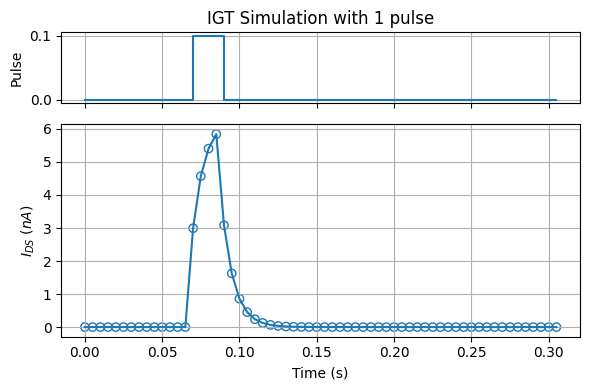

In [20]:
TIME_RESOLUTION = 0.005

pulse_train = np.concatenate((
    np.zeros(14),
    create_pulse_train(0, 0.1, 4, 0, 1),
    np.zeros(44)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with 1 pulse")

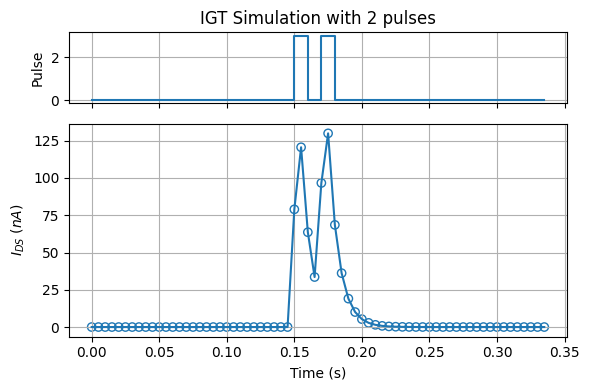

In [21]:
TIME_RESOLUTION = 0.005

pulse_train = np.concatenate((
    np.zeros(30),
    create_pulse_train(0, 3, 2, 2, 2),
    np.zeros(30)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, title="IGT Simulation with 2 pulses")
plt.show()

In [22]:
BETA = 0.56
TAU = 2.6 #ms
TAU_DL = 257 #ms
K = 700 #nA

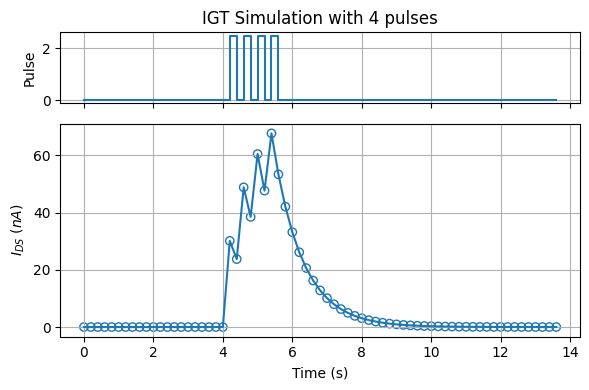

In [23]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(1),
    np.zeros(20),
    create_pulse_train(0, 2.5, 1, 1, 4),
    np.zeros(40)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with 4 pulses")

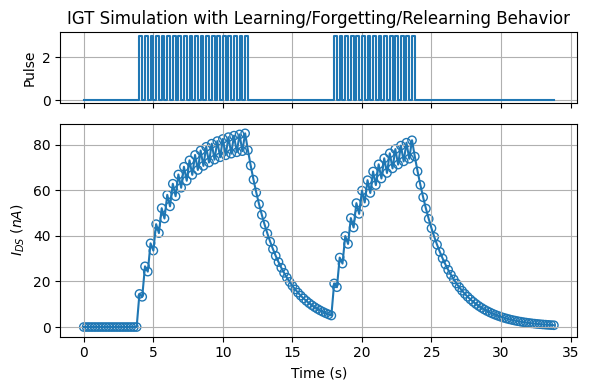

In [38]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 20),
    np.zeros(30),
    create_pulse_train(0, 3, 1, 1, 15),
    np.zeros(50)
))

out_current = generate_out_current(pulse_train, K, 0.8, 4, True, "IGT Simulation with Learning/Forgetting/Relearning Behavior")

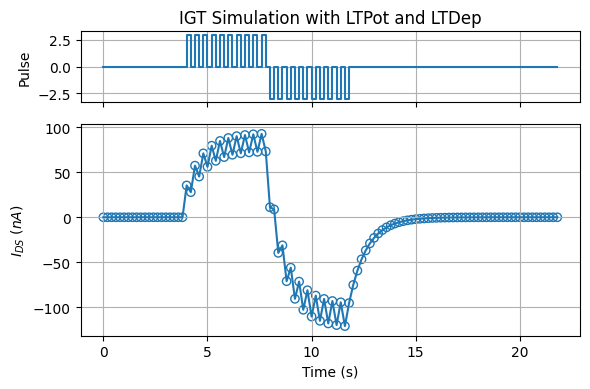

In [25]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 10),
    create_pulse_train(0, -3, 1, 1, 10),
    np.zeros(50)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with LTPot and LTDep")

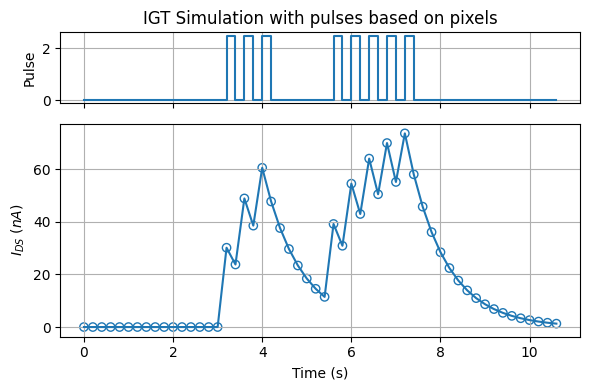

In [26]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(8*2),
    create_pulse_train(0, 2.5, 1, 1, 3),
    np.zeros(3*2),
    create_pulse_train(0, 2.5, 1, 1, 5),
    np.zeros(8*2)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with pulses based on pixels")

In [27]:
def current_to_voltage(current_in_infinity, k, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    # if k > current_in_infinity.any():
    #     print(current_in_infinity)
        
    return np.power(np.log(1/(1-(current_in_infinity/k))), 1/curvature) * scale_voltage + threshold_voltage

In [28]:
from IPython.display import clear_output
from ipywidgets import interact, IntSlider

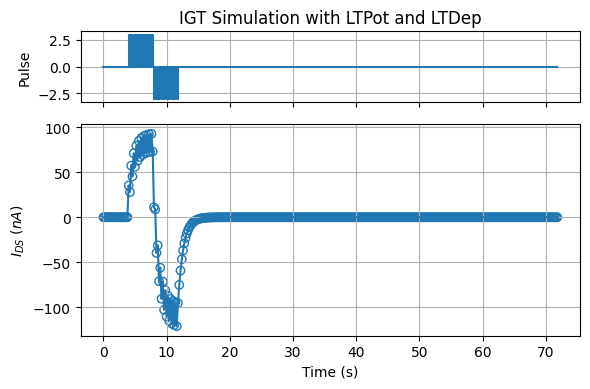

interactive(children=(IntSlider(value=0, description='qtd'), Output()), _dom_classes=('widget-interact',))

<function __main__.update_plots(qtd)>

In [29]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 10),
    create_pulse_train(0, -3, 1, 1, 10),
    np.zeros(300)
))

initial_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with LTPot and LTDep")

def update_plots(qtd):
    clear_output(wait=True)
    plt.close("all")

    out_current = initial_current.copy()

    for _ in range(qtd):
        out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU)

    out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, f"IGT Simulation after {qtd+1} iterations", ((0,70), (-120,120)))

interact(
    update_plots,
    qtd = IntSlider(value=0, min=0, max=100)
)


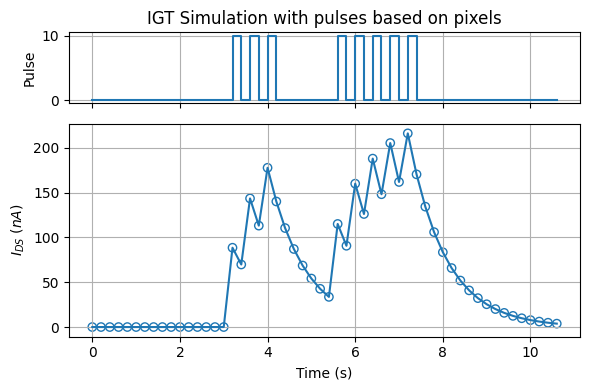

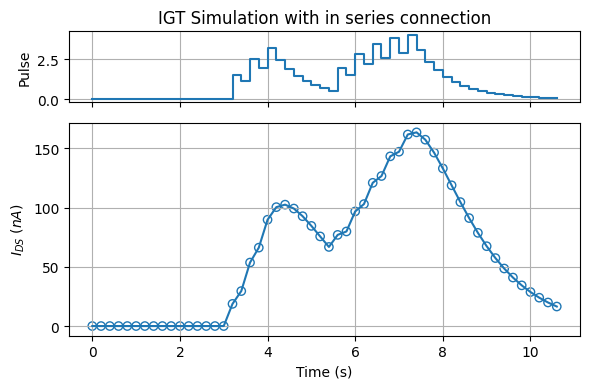

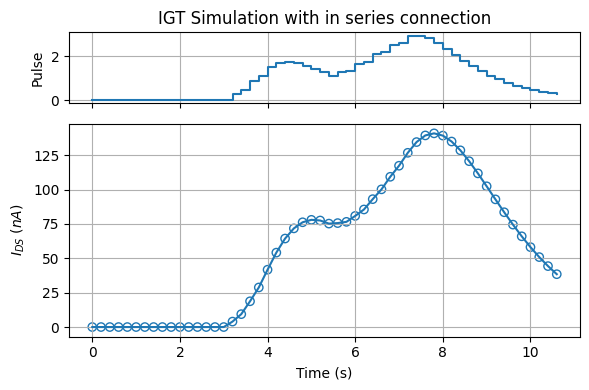

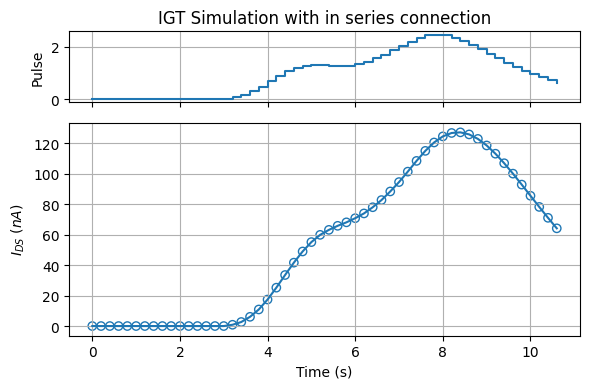

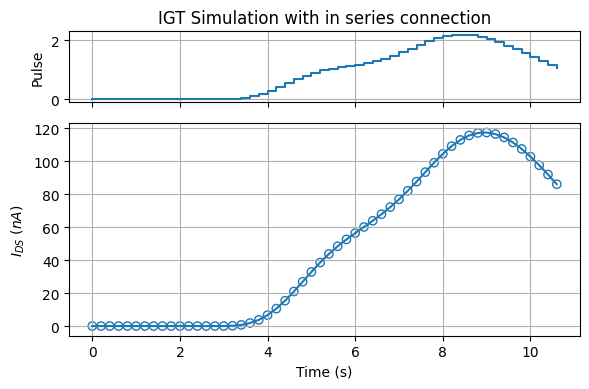

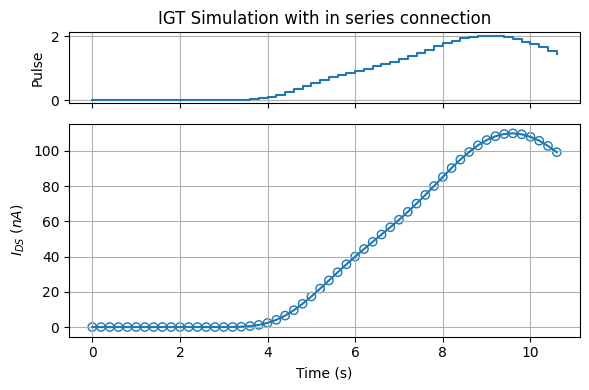

In [30]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(8*2),
    create_pulse_train(0, 10, 1, 1, 3),
    np.zeros(3*2),
    create_pulse_train(0, 10, 1, 1, 5),
    np.zeros(8*2)
))

out_current = generate_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with pulses based on pixels")
out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, "IGT Simulation with in series connection")
out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, "IGT Simulation with in series connection")
out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, "IGT Simulation with in series connection")
out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, "IGT Simulation with in series connection")
out_current = generate_out_current(current_to_voltage(out_current, K), K, BETA, TAU, True, "IGT Simulation with in series connection")

## References

[1] Zhu, L., Wan, X., Lin, J., Chen, P., Luo, Z., Sun, H., Yan, S., Tan, C. L., Yu, Z., & Xu, Y. (2025). *Reservoir computing for image processing based on ion-gated flexible organic transistors with nonlinear synaptic dynamics*. **Organic Electronics, 139**, 107199. https://doi.org/10.1016/j.orgel.2025.107199

[2] Chang Jin Wan, Li Qiang Zhu, Xiang Wan, Yi Shi, Qing Wan; *Organic/inorganic hybrid synaptic transistors gated by proton conducting methylcellulose films*. **Appl. Phys. Lett. 25 January 2016; 108 (4)**: 043508. https://doi.org/10.1063/1.4941080